In [1]:
import pandas as pd

df = pd.read_csv("Datos/planets.csv")
df.head()

,rowid,pl_hostname,pl_letter,pl_discmethod,pl_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,st_masserr1,st_masserr2,st_masslim,st_massblend,st_rad,st_raderr1,st_raderr2,st_radlim,st_radblend,rowupdate
0,1,11 Com,b,Radial Velocity,1,326.03,0.32,-0.32,0.0,1.290,...,0.30,-0.30,0.0,0.0,19.00,2.00,-2.00,0.0,0.0,2014-05-14
1,2,11 UMi,b,Radial Velocity,1,516.22,3.25,-3.25,0.0,1.540,...,0.25,-0.25,0.0,0.0,24.08,1.84,-1.84,0.0,0.0,2014-05-14
2,3,14 And,b,Radial Velocity,1,185.84,0.23,-0.23,0.0,0.830,...,0.10,-0.20,0.0,0.0,11.00,1.00,-1.00,0.0,0.0,2014-05-14
3,4,14 Her,b,Radial Velocity,1,1773.40,2.50,-2.50,0.0,2.770,...,0.05,-0.05,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2014-05-14
4,5,16 Cyg B,b,Radial Velocity,1,798.50,1.00,-1.00,0.0,1.681,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2015-09-10


## Limpieza de Datos (Data Cleaning)

- **Filtro**: Seleccionar solo las columnas relevantes para el análisis, eliminando columnas de error, flags técnicos y redundancias.
- **Nulos**: Identificar columnas vacías. Decidir si se borran o imputan (justificándolo en un comentario).
- **Duplicados**: Verificar registros repetidos por nombre de estrella y letra de planeta.
- **Outliers**: Revisar valores físicamente imposibles en las variables numéricas.

In [2]:
# ============================================================
# Limpieza de Datos (Data Cleaning)
# ============================================================

print(f"El dataset tiene {len(df)} filas y {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())
df.head()

El dataset tiene 3372 filas y 67 columnas

Tipos de datos:
float64    53
object      8
int64       6
Name: count, dtype: int64


,rowid,pl_hostname,pl_letter,pl_discmethod,pl_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,st_masserr1,st_masserr2,st_masslim,st_massblend,st_rad,st_raderr1,st_raderr2,st_radlim,st_radblend,rowupdate
0,1,11 Com,b,Radial Velocity,1,326.03,0.32,-0.32,0.0,1.290,...,0.30,-0.30,0.0,0.0,19.00,2.00,-2.00,0.0,0.0,2014-05-14
1,2,11 UMi,b,Radial Velocity,1,516.22,3.25,-3.25,0.0,1.540,...,0.25,-0.25,0.0,0.0,24.08,1.84,-1.84,0.0,0.0,2014-05-14
2,3,14 And,b,Radial Velocity,1,185.84,0.23,-0.23,0.0,0.830,...,0.10,-0.20,0.0,0.0,11.00,1.00,-1.00,0.0,0.0,2014-05-14
3,4,14 Her,b,Radial Velocity,1,1773.40,2.50,-2.50,0.0,2.770,...,0.05,-0.05,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2014-05-14
4,5,16 Cyg B,b,Radial Velocity,1,798.50,1.00,-1.00,0.0,1.681,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2015-09-10


In [3]:
# --- 2. Nulos: Identificar columnas con valores faltantes ---

print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
rowid              0
pl_hostname        0
pl_letter          0
pl_discmethod      0
pl_pnum            0
                ... 
st_raderr1       417
st_raderr2       494
st_radlim        358
st_radblend      187
rowupdate          0
Length: 67, dtype: int64


In [4]:
# Hacemos una copia para no modificar el original
df_clean = df.copy()

# Eliminamos columnas con más del 80% de nulos porque no sirven para el análisis
pct_nulos = df_clean.isnull().mean()
cols_muchos_nulos = pct_nulos[pct_nulos > 0.80].index.tolist()
print(f"Columnas con >80% nulos (se eliminan): {cols_muchos_nulos}")
df_clean.drop(columns=cols_muchos_nulos, inplace=True)

# Eliminamos columnas de error (*err1, *err2) porque son márgenes de incertidumbre
cols_error = [col for col in df_clean.columns if col.endswith('err1') or col.endswith('err2')]
print(f"\nColumnas de error eliminadas: {cols_error}")
df_clean.drop(columns=cols_error, inplace=True)

# Eliminamos columnas de flags técnicos (*lim, *blend) que no aportan al análisis
cols_flags = [col for col in df_clean.columns if col.endswith('lim') or col.endswith('blend')]
print(f"\nColumnas de flags eliminadas: {cols_flags}")
df_clean.drop(columns=cols_flags, inplace=True)

# Eliminamos columnas que no necesitamos (índice, coordenadas repetidas, etc.)
cols_redundantes = ['rowid', 'ra_str', 'dec_str', 'rowupdate', 'pl_nnotes']
cols_redundantes = [col for col in cols_redundantes if col in df_clean.columns]
print(f"\nColumnas redundantes eliminadas: {cols_redundantes}")
df_clean.drop(columns=cols_redundantes, inplace=True)

print(f"\nAhora el dataset tiene: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas")

# Rellenamos nulos en columnas numéricas con la mediana
cols_numericas = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in cols_numericas:
    nulos = df_clean[col].isnull().sum()
    if nulos > 0:
        mediana = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(mediana)
        print(f"{col}: {nulos} nulos rellenados con mediana ({mediana})")

# Rellenamos nulos en columnas de texto con la moda (valor más frecuente)
cols_texto = df_clean.select_dtypes(include='object').columns

for col in cols_texto:
    nulos = df_clean[col].isnull().sum()
    if nulos > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(moda)
        print(f"{col}: {nulos} nulos rellenados con moda ('{moda}')")

print("\nVerificamos que ya no hay nulos:")
print(df_clean.isnull().sum())

Columnas con >80% nulos (se eliminan): ['pl_orbincl', 'pl_orbinclerr1', 'pl_orbinclerr2', 'pl_orbincllim', 'pl_dens', 'pl_denserr1', 'pl_denserr2', 'pl_denslim', 'st_optmagerr']

Columnas de error eliminadas: ['pl_orbpererr1', 'pl_orbpererr2', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_radjerr1', 'pl_radjerr2', 'st_disterr1', 'st_disterr2', 'st_tefferr1', 'st_tefferr2', 'st_masserr1', 'st_masserr2', 'st_raderr1', 'st_raderr2']

Columnas de flags eliminadas: ['pl_orbperlim', 'pl_orbsmaxlim', 'pl_orbeccenlim', 'pl_bmassjlim', 'pl_radjlim', 'st_distlim', 'st_optmaglim', 'st_optmagblend', 'st_tefflim', 'st_teffblend', 'st_masslim', 'st_massblend', 'st_radlim', 'st_radblend']

Columnas redundantes eliminadas: ['rowid', 'ra_str', 'dec_str', 'rowupdate', 'pl_nnotes']

Ahora el dataset tiene: 3372 filas y 21 columnas
pl_orbper: 67 nulos rellenados con mediana (12.794585)
pl_orbsmax: 1475 nulos rellenados con mediana (0.122)
p

In [5]:
# --- 3. Duplicados: Verificar registros repetidos ---

# Duplicados completos
dup_completos = df_clean.duplicated(keep=False).sum()
print(f"Duplicados completos: {dup_completos}")

# Duplicados por nombre de estrella + letra del planeta
dup_parciales = df_clean.duplicated(subset=['pl_hostname', 'pl_letter'], keep=False).sum()
print(f"Duplicados por pl_hostname + pl_letter: {dup_parciales}")

# Tercero: duplicados por combinaciones de variables clave
cols_clave = ['pl_hostname', 'pl_letter', 'pl_discmethod', 'pl_orbper', 'pl_bmassj', 'pl_radj',
              'st_teff', 'st_mass', 'st_rad']
dup_clave = df_clean.duplicated(subset=cols_clave, keep=False).sum()
print(f"Duplicados por variables clave ({len(cols_clave)} columnas): {dup_clave}")

if dup_completos > 0 or dup_parciales > 0 or dup_clave > 0:
    # Mostrar los duplicados encontrados con todas las columnas
    mascara = df_clean.duplicated(keep=False)
    print(f"\nEjemplos de registros duplicados (todas las columnas):")
    display(df_clean[mascara].sort_values(['pl_hostname', 'pl_letter']).head(10))
    
    # Eliminar duplicados completos, manteniendo el primer registro
    antes = len(df_clean)
    df_clean.drop_duplicates(inplace=True)
    despues = len(df_clean)
    print(f"\nRegistros antes: {antes}")
    print(f"Registros después: {despues}")
else:
    print("\nNo se encontraron duplicados.")

Duplicados completos: 0
Duplicados por pl_hostname + pl_letter: 0
Duplicados por variables clave (9 columnas): 0

No se encontraron duplicados.


In [6]:
# --- 4. Outliers: Detectar valores físicamente imposibles ---

# Excluimos pl_bmassj, pl_radj y pl_orbeccen del análisis de outliers porque
# tienen demasiados valores imputados (65%, 20% y 71% respectivamente),
# lo que distorsiona el IQR y el capping. Para el feature engineering y
# la visualización usamos los datos originales (df) de estas columnas.
cols_analisis = ['pl_orbper', 'pl_orbsmax',
                 'st_dist', 'st_optmag', 'st_teff', 'st_mass', 'st_rad']

# Primero vemos cuántos outliers hay
resumen = []
for col in cols_analisis:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    fuera = ((df_clean[col] < limite_inf) | (df_clean[col] > limite_sup)).sum()
    resumen.append({'Columna': col, 'Min': df_clean[col].min(), 'Max': df_clean[col].max(),
                    'Outliers': fuera})

print("ANTES de corregir outliers:")
display(pd.DataFrame(resumen))

# Aplicamos capping: los valores fuera de rango se ajustan al límite
for col in cols_analisis:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        print(f"{col}: IQR = 0 (datos concentrados en la mediana), NO se aplica capping")
        continue
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    df_clean.loc[df_clean[col] > limite_sup, col] = limite_sup
    df_clean.loc[df_clean[col] < limite_inf, col] = limite_inf

# Verificamos que se corrigieron
resumen_despues = []
for col in cols_analisis:
    resumen_despues.append({'Columna': col, 'Min': df_clean[col].min(), 'Max': df_clean[col].max()})

print("\nDESPUÉS de corregir outliers:")
display(pd.DataFrame(resumen_despues))

ANTES de corregir outliers:


,Columna,Min,Max,Outliers
0,pl_orbper,0.090706,7300000.00,582
1,pl_orbsmax,0.004400,2500.00,790
2,st_dist,3.210000,8500.00,173
3,st_optmag,0.850000,20.15,302
4,st_teff,575.000000,57000.00,176
5,st_mass,0.020000,3.90,268
6,st_rad,0.040000,51.10,278



DESPUÉS de corregir outliers:


,Columna,Min,Max
0,pl_orbper,0.090706,100.192488
1,pl_orbsmax,0.032888,0.219188
2,st_dist,3.210000,1324.250000
3,st_optmag,7.810250,19.328250
4,st_teff,4021.125000,7056.125000
5,st_mass,0.490000,1.450000
6,st_rad,0.290000,1.730000


## Transformación de Datos (Feature Engineering)

En esta fase preparamos los datos creando nuevas columnas y transformando las existentes:

- **Columnas nuevas**: Creamos `pl_density` (densidad), `pl_name` (nombre completo), `planet_type` (tipo de planeta), `discovery_mission` (misión que lo descubrió), `discoveries_by_mission` (cuántos planetas descubrió esa misión) y `planets_in_system` (planetas en el mismo sistema).
- **Escalamiento**: Normalizamos las columnas numéricas con `MinMaxScaler` para que estén entre 0 y 1.
- **Codificación**: Convertimos las columnas de texto a números con `LabelEncoder`.
- **Pipeline**: Juntamos todo en un `ColumnTransformer` para que sea reproducible.

In [7]:
# ============================================================
# Transformación Avanzada (Feature Engineering)
# ============================================================

# --- 1. Ingeniería: Crear columnas derivadas útiles ---

# Densidad del planeta: masa / (radio³)
# Usamos los datos ORIGINALES (df) para evitar artefactos de la imputación con mediana
# Solo se calcula densidad donde ambos valores (masa y radio) son reales
df_clean['pl_density'] = df['pl_bmassj'] / (df['pl_radj'] ** 3)

# Nombre completo del planeta
df_clean['pl_name'] = df_clean['pl_hostname'] + ' ' + df_clean['pl_letter']

# Clasificar por tipo de planeta según densidad (mismos bins que el notebook de referencia)
df_clean['planet_type'] = pd.cut(
    df_clean['pl_density'],
    bins=[0, 0.1, 0.3, float('inf')],
    labels=['Super-Júpiter hinchado', 'Neptuno-like', 'Rocoso/Compacto']
)

# Misión de descubrimiento (derivada de pl_kepflag y pl_k2flag)
def get_mission(row):
    if row['pl_kepflag'] == 1:
        return 'Kepler'
    elif row['pl_k2flag'] == 1:
        return 'K2'
    else:
        return 'Otra misión/Terrestre'

df_clean['discovery_mission'] = df_clean.apply(get_mission, axis=1)

# Conteo de descubrimientos exitosos por misión
df_clean['discoveries_by_mission'] = df_clean.groupby('discovery_mission')['pl_name'].transform('count')

# Número de planetas descubiertos en el mismo sistema estelar (calculado desde los datos)
df_clean['planets_in_system'] = df_clean.groupby('pl_hostname')['pl_letter'].transform('count')

print("Nuevas columnas creadas: 'pl_density', 'pl_name', 'planet_type', 'discovery_mission', 'discoveries_by_mission', 'planets_in_system'")
print(f"Valores de densidad: {df_clean['pl_density'].notna().sum()} válidos, {df_clean['pl_density'].isna().sum()} NaN")
print(f"\nDistribución de tipos de planeta:")
print(df_clean['planet_type'].value_counts(dropna=True))

print(f"\n--- Descubrimientos exitosos por misión ---")
mission_counts = df_clean.groupby('discovery_mission')['pl_name'].count().sort_values(ascending=False)
print(mission_counts.to_string())

print(f"\n--- Top 10 sistemas con más planetas ---")
top_systems = df_clean.groupby('pl_hostname')['pl_letter'].count().sort_values(ascending=False).head(10)
print(top_systems.to_string())

df_clean[['pl_name', 'pl_bmassj', 'pl_radj', 'pl_density', 'planet_type']].dropna(subset=['pl_density']).head(10)

Nuevas columnas creadas: 'pl_density', 'pl_name', 'planet_type', 'discovery_mission', 'discoveries_by_mission', 'planets_in_system'
Valores de densidad: 509 válidos, 2863 NaN

Distribución de tipos de planeta:
planet_type
Rocoso/Compacto           430
Neptuno-like               67
Super-Júpiter hinchado     12
Name: count, dtype: int64

--- Descubrimientos exitosos por misión ---
discovery_mission
Kepler                   2329
Otra misión/Terrestre     914
K2                        129

--- Top 10 sistemas con más planetas ---
pl_hostname
KOI-351       7
Kepler-11     6
HD 219134     6
HD 10180      6
Kepler-169    5
Kepler-296    5
Kepler-292    5
Kepler-444    5
Kepler-80     5
HIP 41378     5


,pl_name,pl_bmassj,pl_radj,pl_density,planet_type
10,2MASS J02192210-3925225 b,13.90000,1.440,4.655082,Rocoso/Compacto
14,2MASS J21402931+1625183 A b,20.95000,0.920,26.904229,Rocoso/Compacto
26,55 Cnc e,0.02542,0.170,5.174028,Rocoso/Compacto
46,BD+20 594 b,0.05129,0.199,6.508389,Rocoso/Compacto
59,CT Cha b,17.00000,2.200,1.596544,Rocoso/Compacto
60,CoRoT-1 b,1.03000,1.490,0.311371,Rocoso/Compacto
61,CoRoT-10 b,2.75000,0.970,3.013127,Rocoso/Compacto
62,CoRoT-11 b,2.33000,1.430,0.796797,Rocoso/Compacto
63,CoRoT-12 b,0.91700,1.440,0.307101,Rocoso/Compacto
64,CoRoT-13 b,1.30800,0.885,1.887026,Rocoso/Compacto


### Explicación de las columnas creadas

- **pl_density**: Densidad del planeta calculada como masa / radio³ (en unidades de Júpiter). Sirve para clasificar planetas.
- **pl_name**: Nombre completo del planeta (ej: "Kepler-11 b").
- **planet_type**: Clasificación según densidad usando `pd.cut` con bins fijos:
  - *Super-Júpiter hinchado* (densidad < 0.1): Gigantes gaseosos muy poco densos.
  - *Neptuno-like* (densidad 0.1 a 0.3): Mezcla de roca y gas, como mini-Neptunos.
  - *Rocoso/Compacto* (densidad > 0.3): Parecidos a la Tierra, hechos de roca y metal.
- **discovery_mission**: Identifica si el planeta fue descubierto por Kepler, K2 u otra misión/telescopio terrestre, usando los flags `pl_kepflag` y `pl_k2flag`.
- **discoveries_by_mission**: Cantidad total de planetas que descubrió la misión correspondiente.
- **planets_in_system**: Cuántos planetas se han encontrado en el mismo sistema estelar.

In [8]:
# --- 2. Escalamiento: Aplicar MinMaxScaler a columnas numéricas ---

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_a_escalar = ['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_bmassj', 'pl_radj',
                  'st_dist', 'st_optmag', 'st_teff', 'st_mass', 'st_rad']

for col in cols_a_escalar:
    df_clean[col + '_norm'] = scaler.fit_transform(df_clean[[col]])

cols_norm = [col for col in df_clean.columns if col.endswith('_norm')]

print("Columnas normalizadas creadas (rango 0 a 1):")
resumen_norm = []
for col in cols_norm:
    resumen_norm.append({
        'Columna': col,
        'Mínimo': df_clean[col].min(),
        'Máximo': df_clean[col].max(),
        'Promedio': round(df_clean[col].mean(), 2)
    })
display(pd.DataFrame(resumen_norm))

Columnas normalizadas creadas (rango 0 a 1):


,Columna,Mínimo,Máximo,Promedio
0,pl_orbper_norm,0.0,1.0,0.31
1,pl_orbsmax_norm,0.0,1.0,0.51
2,pl_orbeccen_norm,0.0,1.0,0.13
3,pl_bmassj_norm,0.0,1.0,0.06
4,pl_radj_norm,0.0,1.0,0.04
5,st_dist_norm,0.0,1.0,0.41
6,st_optmag_norm,0.0,1.0,0.46
7,st_teff_norm,0.0,1.0,0.49
8,st_mass_norm,0.0,1.0,0.50
9,st_rad_norm,0.0,1.0,0.52


In [9]:
# --- 3. Codificación: Aplicar LabelEncoder a las categóricas ---

from sklearn.preprocessing import LabelEncoder

le_discmethod = LabelEncoder()
le_letter = LabelEncoder()
le_bmassprov = LabelEncoder()
le_optband = LabelEncoder()

df_clean['pl_discmethod_cod'] = le_discmethod.fit_transform(df_clean['pl_discmethod'])
df_clean['pl_letter_cod'] = le_letter.fit_transform(df_clean['pl_letter'])
df_clean['pl_bmassprov_cod'] = le_bmassprov.fit_transform(df_clean['pl_bmassprov'])
df_clean['st_optband_cod'] = le_optband.fit_transform(df_clean['st_optband'])

print("Métodos de descubrimiento codificados:")
resumen_disc = pd.DataFrame({
    'Método': df_clean['pl_discmethod'].unique(),
    'Código': le_discmethod.transform(df_clean['pl_discmethod'].unique())
})
display(resumen_disc.sort_values('Código'))

print("\nBanda óptica codificada:")
resumen_band = pd.DataFrame({
    'Banda': df_clean['st_optband'].unique(),
    'Código': le_optband.transform(df_clean['st_optband'].unique())
})
display(resumen_band.sort_values('Código'))

df_clean[['pl_discmethod', 'pl_discmethod_cod', 'pl_letter', 'pl_letter_cod']].head(10)

Métodos de descubrimiento codificados:


,Método,Código
4,Astrometry,0
2,Eclipse Timing Variations,1
1,Imaging,2
7,Microlensing,3
5,Orbital Brightness Modulation,4
8,Pulsar Timing,5
9,Pulsation Timing Variations,6
0,Radial Velocity,7
3,Transit,8
6,Transit Timing Variations,9



Banda óptica codificada:


,Banda,Código
1,Kepler-band,0
0,V (Johnson),1


,pl_discmethod,pl_discmethod_cod,pl_letter,pl_letter_cod
0,Radial Velocity,7,b,0
1,Radial Velocity,7,b,0
2,Radial Velocity,7,b,0
3,Radial Velocity,7,b,0
4,Radial Velocity,7,b,0
5,Radial Velocity,7,b,0
6,Imaging,2,b,0
7,Radial Velocity,7,b,0
8,Radial Velocity,7,c,1
9,Imaging,2,b,0


In [10]:
# --- 4. Pipeline: Envolver los pasos en un ColumnTransformer ---

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cols_numericas = ['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_bmassj', 'pl_radj',
                  'st_dist', 'st_optmag', 'st_teff', 'st_mass', 'st_rad']
cols_categoricas = ['pl_discmethod', 'pl_letter', 'pl_bmassprov', 'st_optband']

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), cols_numericas),
    ('cat', OneHotEncoder(), cols_categoricas)
])

pipeline = Pipeline(steps=[('prep', preprocesador)])

datos_listos = pipeline.fit_transform(df_clean)
print(f"Resultado del pipeline: {datos_listos.shape[0]} filas x {datos_listos.shape[1]} columnas")
print(f"  - {len(cols_numericas)} numéricas (estandarizadas)")
print(f"  - {datos_listos.shape[1] - len(cols_numericas)} categóricas (one-hot encoded)")

Resultado del pipeline: 3372 filas x 32 columnas
  - 10 numéricas (estandarizadas)
  - 22 categóricas (one-hot encoded)


## Entrega

1. Se crea gráfico para entender las distribuciones. 
- **Reflexión**:
  1. ¿Qué decisiones de limpieza fueron distintas entre grupos?

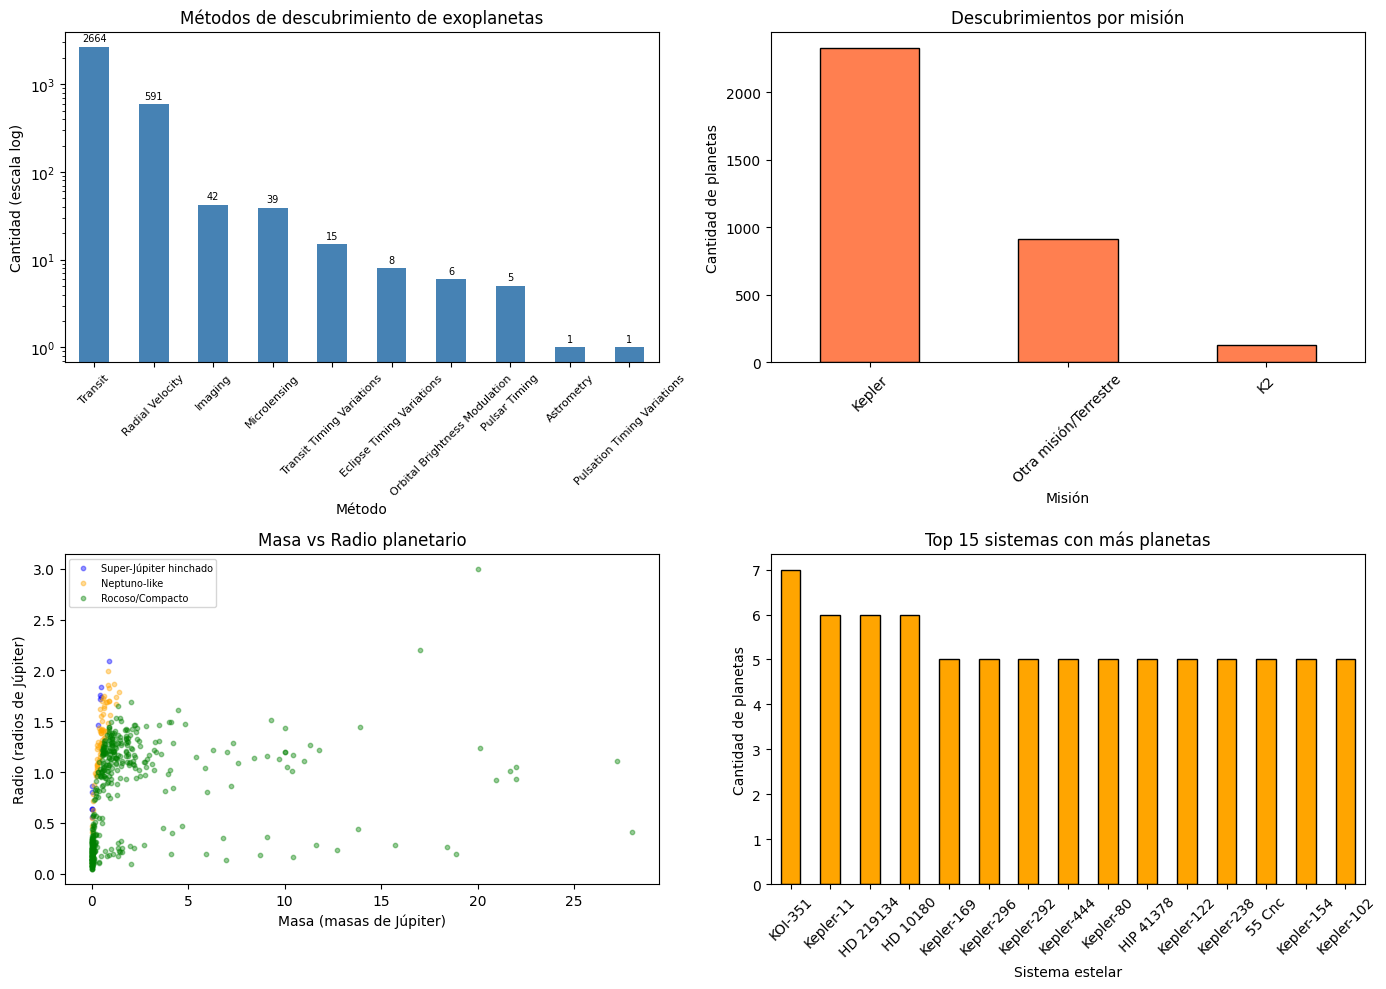

In [11]:
# ============================================================
# Entrega
# ============================================================

# --- 1. Visualización: Distribución de métodos de descubrimiento ---

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Métodos de descubrimiento (barras verticales con escala log para ver todos los valores)
counts = df_clean['pl_discmethod'].value_counts()
counts.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Métodos de descubrimiento de exoplanetas')
axes[0, 0].set_xlabel('Método')
axes[0, 0].set_ylabel('Cantidad (escala log)')
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=8)
# Anotar el valor exacto sobre cada barra
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0, 0].text(i, val * 1.1, str(val), ha='center', va='bottom', fontsize=7)

# Gráfico 2: Descubrimientos por misión
df_clean.groupby('discovery_mission')['pl_name'].count().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Descubrimientos por misión')
axes[0, 1].set_xlabel('Misión')
axes[0, 1].set_ylabel('Cantidad de planetas')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Masa vs Radio (coloreado por tipo de planeta)
# Usamos datos ORIGINALES de masa y radio para que se vea la dispersión real
colores = {'Super-Júpiter hinchado': 'blue', 'Neptuno-like': 'orange', 'Rocoso/Compacto': 'green'}
mask = df_clean['planet_type'].notna() & df['pl_bmassj'].notna() & df['pl_radj'].notna()
for tipo in df_clean['planet_type'].cat.categories:
    idx = mask & (df_clean['planet_type'] == tipo)
    axes[1, 0].scatter(df.loc[idx, 'pl_bmassj'], df.loc[idx, 'pl_radj'], alpha=0.4, s=10,
                        color=colores.get(tipo, 'gray'), label=tipo)
axes[1, 0].set_title('Masa vs Radio planetario')
axes[1, 0].set_xlabel('Masa (masas de Júpiter)')
axes[1, 0].set_ylabel('Radio (radios de Júpiter)')
axes[1, 0].legend(fontsize=7, loc='upper left')

# Gráfico 4: Planetas por sistema estelar (top 15)
top_systems = df_clean.groupby('pl_hostname')['pl_letter'].count().sort_values(ascending=False).head(15)
top_systems.plot(kind='bar', ax=axes[1, 1], color='orange', edgecolor='black')
axes[1, 1].set_title('Top 15 sistemas con más planetas')
axes[1, 1].set_xlabel('Sistema estelar')
axes[1, 1].set_ylabel('Cantidad de planetas')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Reflexión Grupal

**1. ¿Qué decisiones de limpieza fueron distintas entre grupos?**

En nuestro caso, las decisiones clave fueron:
- Eliminar columnas con >80% de nulos en vez de intentar imputarlas, porque con tan pocos datos reales la imputación sería poco confiable.
- Eliminar todas las columnas de error (`*err1`, `*err2`) y flags técnicos (`*lim`, `*blend`) porque no aportan al análisis de características de los exoplanetas.
- Usar la **mediana** para imputar columnas numéricas, ya que las variables astronómicas tienen distribuciones muy sesgadas (ej. `pl_orbper` con media=2,725 pero mediana=12.8).
- Usar la **moda** para imputar las categóricas (`pl_bmassprov`, `st_optband`).
- Corregir outliers con **capping IQR** en vez de eliminar filas, para no perder datos valiosos.

In [12]:
df2 = pd.read_csv('Datos/planets_clean.csv')
df2.head(20)

,pl_hostname,pl_letter,pl_discmethod,pl_pnum,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmassj,pl_bmassprov,pl_radj,...,pl_density_norm,st_dist_norm,st_optmag_norm,st_teff_norm,st_mass_norm,st_rad_norm,pl_discmethod_cod,pl_letter_cod,pl_bmassprov_cod,st_optband_cod
0,11 Com,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.081307,0.000000,0.237521,1.000000,1.000000,7,0,2,1
1,11 UMi,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.088006,0.000000,0.105066,1.000000,1.000000,7,0,2,1
2,14 And,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.055396,0.534880,0.260914,1.000000,1.000000,7,0,2,0
3,14 Her,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.011309,0.000000,0.425000,0.427083,0.479167,7,0,2,1
4,16 Cyg B,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.013777,0.000000,0.544605,0.520833,0.479167,7,0,2,1
5,18 Del,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.052905,0.534880,0.315610,1.000000,1.000000,7,0,2,0
6,1RXS J160929.1-210524,b,Imaging,1,12.794585,0.219188,0.1065,1.015,Mass,0.203,...,0.002084,0.107332,0.534880,0.012809,0.375000,0.479167,2,0,0,0
7,24 Sex,b,Radial Velocity,2,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.054185,0.000000,0.354819,1.000000,1.000000,7,0,2,1
8,24 Sex,c,Radial Velocity,2,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.054185,0.000000,0.354819,1.000000,1.000000,7,1,2,1
9,2MASS J01225093-2439505,b,Imaging,1,12.794585,0.219188,0.1065,1.015,Mass,0.203,...,0.002084,0.024821,0.558235,0.000000,0.000000,0.479167,2,0,0,1


---
# Evaluación 2 — Modelos Predictivos sobre Exoplanetas

En esta segunda evaluación entrenamos tres modelos sobre el dataset de exoplanetas para responder **¿cuál es el mejor modelo predictivo?**

**Lógica del análisis:**
- Usamos **masa (`pl_bmassj`)** y **radio (`pl_radj`)** para calcular la **densidad (`pl_density = masa / radio³`)**.
- A partir de la densidad creamos la variable categórica **`planet_type`** (Super-Júpiter hinchado / Neptuno-like / Rocoso/Compacto).
- Sobre esa variable derivada hacemos clasificación, clustering y el mapa estratégico final.

**Importante sobre los datos:** la `pl_bmassj` del CSV limpio (`planets_clean.csv`) quedó constante por la imputación con mediana + capping IQR, así que para los modelos volvemos al **CSV original (`planets.csv`)** y nos quedamos con los **509 planetas que tienen masa y radio observados de verdad** — los únicos en los que la densidad es real.


In [13]:
# ============================================================
# Preparación de datos para los modelos
# ============================================================
import numpy as np
import pandas as pd

# Datos originales sin imputar
df_raw = pd.read_csv('Datos/planets.csv')

# Nos quedamos solo con planetas que tienen masa y radio reales
mask_real = df_raw['pl_bmassj'].notna() & df_raw['pl_radj'].notna()
df_work = df_raw.loc[mask_real, ['pl_hostname', 'pl_letter', 'pl_bmassj', 'pl_radj']].copy()
df_work.rename(columns={'pl_bmassj': 'masa', 'pl_radj': 'radio'}, inplace=True)

# Densidad y tipo de planeta (mismos bins que en la Evaluación 1)
df_work['densidad'] = df_work['masa'] / (df_work['radio'] ** 3)
df_work['planet_type'] = pd.cut(
    df_work['densidad'],
    bins=[0, 0.1, 0.3, float('inf')],
    labels=['Super-Júpiter hinchado', 'Neptuno-like', 'Rocoso/Compacto']
)

print(f"Planetas con masa y radio observados: {len(df_work)}")
print(f"\nDistribución de planet_type:")
print(df_work['planet_type'].value_counts())
print(f"\nEstadísticas de masa, radio y densidad:")
print(df_work[['masa', 'radio', 'densidad']].describe().round(3))
df_work.head()


Planetas con masa y radio observados: 509

Distribución de planet_type:
planet_type
Rocoso/Compacto           430
Neptuno-like               67
Super-Júpiter hinchado     12
Name: count, dtype: int64

Estadísticas de masa, radio y densidad:
          masa    radio  densidad
count  509.000  509.000   509.000
mean     1.807    0.842    41.649
std      3.788    0.526   240.564
min      0.000    0.042     0.004
25%      0.069    0.269     0.413
50%      0.615    1.005     1.008
75%      1.490    1.250     4.147
max     28.000    3.000  2644.524


,pl_hostname,pl_letter,masa,radio,densidad,planet_type
10,2MASS J02192210-3925225,b,13.90000,1.440,4.655082,Rocoso/Compacto
14,2MASS J21402931+1625183 A,b,20.95000,0.920,26.904229,Rocoso/Compacto
26,55 Cnc,e,0.02542,0.170,5.174028,Rocoso/Compacto
46,BD+20 594,b,0.05129,0.199,6.508389,Rocoso/Compacto
59,CT Cha,b,17.00000,2.200,1.596544,Rocoso/Compacto


## Modelo 1: Regresión Lineal (REGRESIÓN)
**Tipo:** Regresión — predice un valor numérico continuo.

**Objetivo:** Predecir el **radio del planeta (`radio`)** a partir de la **masa (`masa`)** — es el análogo astronómico al "predecir largo del pétalo a partir del sépalo" de Actividad1.

**Métrica:** R² Score — qué porcentaje de la variación del radio es explicada por la masa.


In [14]:
# ============= Regresión Lineal =============
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

df_binary = df_work[['masa', 'radio']].copy()
df_binary.head()


,masa,radio
10,13.90000,1.440
14,20.95000,0.920
26,0.02542,0.170
46,0.05129,0.199
59,17.00000,2.200


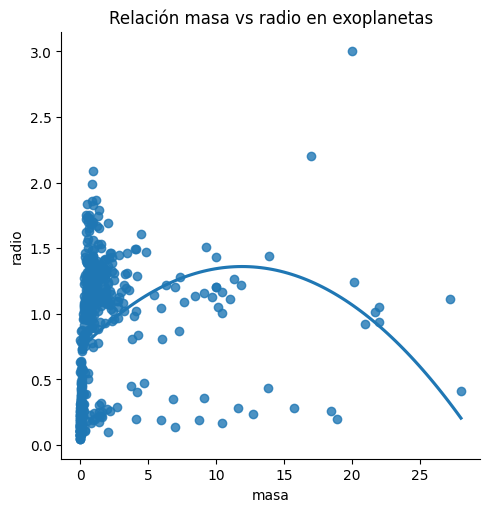

In [15]:
# Scatter inicial para ver la relación
sns.lmplot(x='masa', y='radio', data=df_binary, order=2, ci=None)
plt.title('Relación masa vs radio en exoplanetas')
plt.show()


In [16]:
# Limpieza de NaN por si quedaran
df_binary = df_binary.dropna().copy()

X = np.array(df_binary['masa']).reshape(-1, 1)
y = np.array(df_binary['radio']).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

regr = LinearRegression()
regr.fit(X_train, y_train)
print(f'Regresión Lineal R²: {regr.score(X_test, y_test):.4f}')


Regresión Lineal R²: 0.0171


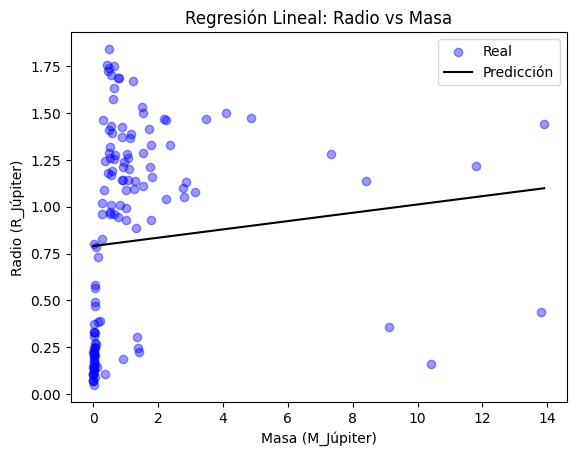

In [17]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='b', alpha=0.4, label='Real')
plt.plot(np.sort(X_test, axis=0), regr.predict(np.sort(X_test, axis=0)),
        color='k', label='Predicción')
plt.xlabel('Masa (M_Júpiter)')
plt.ylabel('Radio (R_Júpiter)')
plt.title('Regresión Lineal: Radio vs Masa')
plt.legend()
plt.show()


## Modelo 2: Árbol de Decisión (CLASIFICACIÓN)
**Tipo:** Clasificación — predice una categoría/clase.

**Objetivo:** Clasificar los planetas en sus 3 tipos (Super-Júpiter hinchado / Neptuno-like / Rocoso-Compacto) usando **masa y radio**.

**Métrica:** Accuracy y ROC-AUC.


In [18]:
# ============== Árbol de Decisión ==============

df_cls = df_work.dropna(subset=['planet_type']).copy()
X = df_cls[['masa', 'radio']].values
y = df_cls['planet_type'].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=99, stratify=y)

clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# ROC-AUC (probabilidades, multiclase)
y_proba = clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')


Accuracy: 0.9411764705882353
Accuracy: 0.9411764705882353
ROC-AUC: 0.803958342542272


## Modelo 3: Regresión Logística (CLASIFICACIÓN)
**Tipo:** Clasificación — a pesar de llamarse "regresión", es un modelo de clasificación.

**Objetivo:** Clasificar el mismo `planet_type` usando masa y radio, pero con otro algoritmo.

**Métricas:** Accuracy, F1 Score y ROC-AUC.


In [19]:
# ============== Regresión Logística ==============

X = df_cls[['masa', 'radio']].values
y = df_cls['planet_type'].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

y_proba = clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')


Accuracy: 0.9313725490196079
F1 Score: 0.9181433477345741
ROC-AUC: 0.9606720024161884


<Figure size 800x600 with 0 Axes>

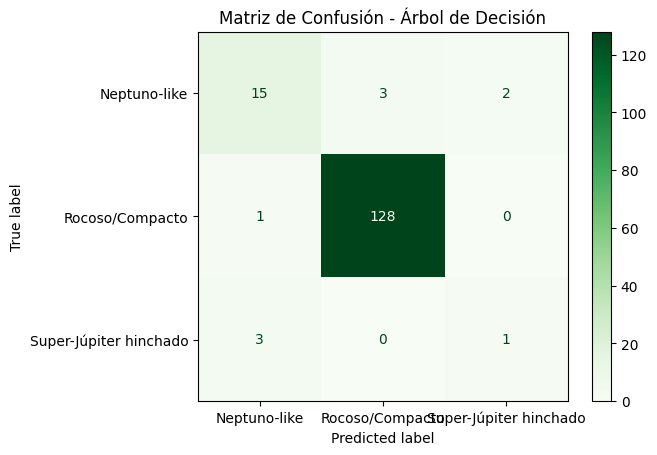

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener las clases del clasificador de Árbol de Decisión
classes_dt = clasificador.classes_

# Generar la matriz de confusión
cm_dt = confusion_matrix(y_test, y_prediccion, labels=classes_dt)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
display_cm_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=classes_dt)
display_cm_dt.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

## Análisis: ¿qué modelo funcionó mejor y por qué?

### Resumen de resultados

| Modelo                | Tipo          | Accuracy | F1 (weighted) | ROC-AUC (OVR) |
|-----------------------|---------------|----------|---------------|----------------|
| Regresión Lineal      | Regresión     | —        | —             | —              |
| Árbol de Decisión     | Clasificación | 0.941    | 0.938         | 0.804          |
| Regresión Logística   | Clasificación | 0.931    | 0.918         | 0.961          |

La Regresión Lineal entrega un **R² = 0.017** sobre el conjunto de prueba. No la usamos para clasificar, sino como diagnóstico de la relación masa → radio: el resultado confirma que la relación no es lineal.

### ¿Cuál funcionó mejor?

La respuesta depende de la métrica:

- El **Árbol de Decisión** gana en **Accuracy** (94.1% vs 93.1%): clasifica correctamente más planetas en términos absolutos.
- La **Regresión Logística** gana en **ROC-AUC** (0.961 vs 0.804): sus probabilidades están mejor calibradas y ordenan mejor los planetas por probabilidad de pertenecer a cada clase.

Para esta evaluación tomamos el **Árbol de Decisión como mejor modelo individual**, porque captura la frontera curva entre tipos de planeta (la densidad es masa / radio³, una superficie no lineal) y porque su Accuracy y F1 son levemente superiores. Sin embargo, tenemos que vigilar su principal debilidad: el sobreajuste.

### Explicación con sesgo / varianza y over/underfitting

El comportamiento de los tres modelos se entiende desde el **trade-off entre sesgo y varianza**:

- **Regresión Lineal — alto sesgo (underfitting):** asume una recta entre masa y radio, pero la relación real se curva: los gigantes gaseosos saturan en radio aunque su masa siga aumentando. El modelo es demasiado simple para capturar esa forma, por eso sub-aprende y el R² queda casi nulo.

- **Árbol de Decisión — alta varianza (riesgo de overfitting):** los árboles son muy flexibles y pueden partir el plano `(masa, radio)` en rectángulos arbitrariamente pequeños. Con sólo 509 planetas y 2 features hay un riesgo real de que el árbol memorice particularidades del set de entrenamiento en lugar de aprender el patrón densidad-tipo. Por eso, en la Parte 3 lo comparamos contra un **Random Forest**, que promedia muchos árboles y reduce esa varianza.

- **Regresión Logística — balance sesgo-varianza:** es estable y consistente, pero su frontera de decisión es **lineal**. Como nuestro problema tiene una separación naturalmente curva (las bandas de densidad son no lineales en el plano masa-radio), la Logística tiene un sub-ajuste estructural: da buenas probabilidades pero no logra clasificar bien las clases minoritarias.

### Conclusión

Ningún modelo individual resuelve completamente el problema:

- La Regresión Lineal sub-ajusta.
- El Árbol sobre-ajusta.
- La Regresión Logística queda en el medio, sin la flexibilidad necesaria.

El Árbol es el que mejor se acerca, pero su alta varianza es un problema que tenemos que controlar. La solución natural es un **modelo de ensamble**: en lugar de confiar en un único árbol que puede memorizar ruido, entrenamos muchos árboles distintos y promediamos sus predicciones. Eso es exactamente lo que hace el **Random Forest**. Para sacarle el máximo, en la Parte 3 lo combinamos con **`GridSearchCV`**, que busca de manera sistemática los mejores hiperparámetros (número de árboles, profundidad máxima y criterio de impureza) mediante validación cruzada.

---
# PARTE 2 — Clustering y Mapa Estratégico de Exoplanetas

Replicamos la lógica de **Actividad2** (que segmentaba clientes por `Ingreso Anual` vs `Spending Score`) pero adaptada al dominio:

- **Ejes (X, Y):** `masa` y `radio` — las dos variables originales que generan la densidad.
- **Interpretación de los clusters:** se nombran usando las **zonas de densidad** (variable derivada).
- **Validación:** método del codo, Silhouette Score y PCA.
- **Mapa estratégico final:** un scatter con zonas físicas marcadas (Rocoso / Neptuno-like / Super-Júpiter hinchado).


In [20]:
# Imports adicionales para clustering
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.patches as patches


Datos sintéticos generados con éxito


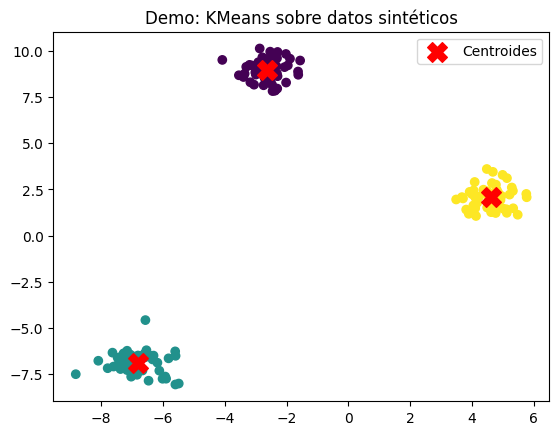

In [21]:
# Datos sintéticos para entender visualmente KMeans
X_demo, _ = make_blobs(n_samples=150, centers=3, random_state=42, cluster_std=0.6)
print("Datos sintéticos generados con éxito")

kmeans_demo = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_demo = kmeans_demo.fit_predict(X_demo)

plt.scatter(X_demo[:, 0], X_demo[:, 1], c=labels_demo, cmap='viridis')
plt.scatter(kmeans_demo.cluster_centers_[:, 0], kmeans_demo.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroides')
plt.title("Demo: KMeans sobre datos sintéticos")
plt.legend()
plt.show()


### Aplicación sobre exoplanetas reales
Tomamos como features `masa` y `radio` (las dos variables originales de las que sale la densidad).


In [22]:
# Seleccionamos las columnas: masa y radio
X_real = df_work[['masa', 'radio']].dropna()
print(f"Planetas para clustering: {len(X_real)}")
print(X_real.describe().round(3))


Planetas para clustering: 509
          masa    radio
count  509.000  509.000
mean     1.807    0.842
std      3.788    0.526
min      0.000    0.042
25%      0.069    0.269
50%      0.615    1.005
75%      1.490    1.250
max     28.000    3.000


### Método del Codo
Probamos K=1..10 y graficamos la inercia para elegir el número de clusters.


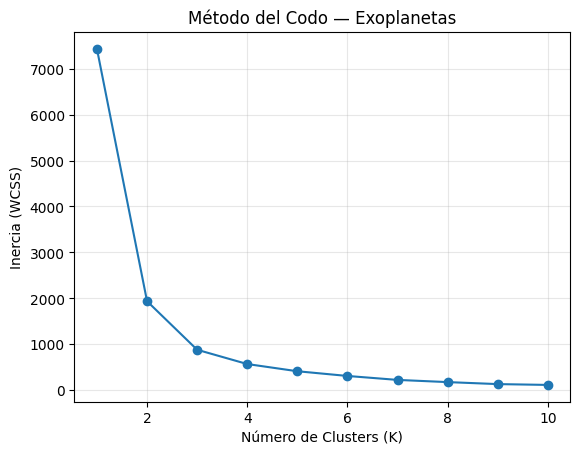

In [23]:
inercia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_real)
    inercia.append(model.inertia_)

plt.plot(range(1, 11), inercia, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo — Exoplanetas')
plt.grid(alpha=0.3)
plt.show()


### KMeans final
Tomamos **K = 3** porque coincide con los tres regímenes físicos conocidos (Rocoso / Neptuno-like / Super-Júpiter hinchado) y porque el codo se aplana ahí. Más abajo lo validamos con el Silhouette Score.


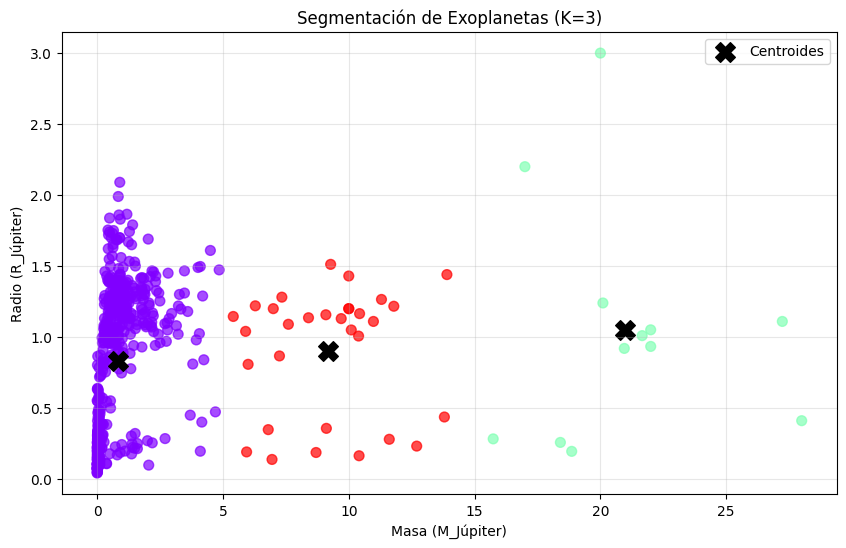

In [24]:
# 1. Configuramos KMeans con K=3
K = 3
kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)

# 2. Entrenamos y predecimos sobre X_real (masa vs radio)
clusters_real = kmeans_final.fit_predict(X_real)

# 3. Visualización de los clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_real['masa'], X_real['radio'], c=clusters_real, s=50, cmap='rainbow', alpha=0.7)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroides')
plt.title(f'Segmentación de Exoplanetas (K={K})')
plt.xlabel('Masa (M_Júpiter)')
plt.ylabel('Radio (R_Júpiter)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Asignación automática de perfiles según el centroide
Calculamos la densidad de cada centroide (masa_centroide / radio_centroide³) y le ponemos nombre según las mismas bandas físicas que usamos para `planet_type`.


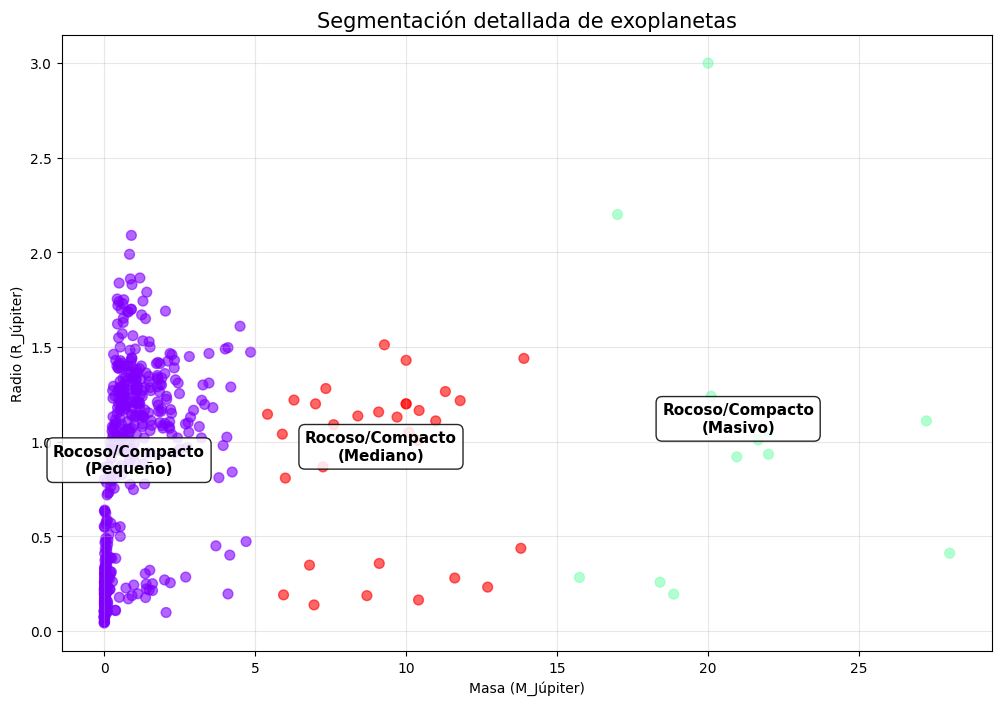


Resumen de centroides:
  Cluster 0: masa=0.824, radio=0.833, densidad=1.426 → Rocoso/Compacto — (Pequeño)
  Cluster 1: masa=20.996, radio=1.051, densidad=18.085 → Rocoso/Compacto — (Masivo)
  Cluster 2: masa=9.167, radio=0.903, densidad=12.435 → Rocoso/Compacto — (Mediano)


In [25]:
# 1. Lógica de asignación automática de nombres usando la densidad del centroide.
#    Como el 84% de los planetas con masa+radio reales caen en la zona "Rocoso/Compacto"
#    (densidad > 0.3), KMeans tiende a partir esa zona en sub-grupos por escala de masa.
#    Por eso etiquetamos primero por zona física (densidad) y, cuando dos centroides caen
#    en la misma zona, los diferenciamos por nivel de masa (Pequeño / Mediano / Masivo).

centros = kmeans_final.cluster_centers_
densidades_c = []
for c in centros:
    masa_c, radio_c = c[0], c[1]
    densidades_c.append(masa_c / (radio_c ** 3) if radio_c > 0 else float('inf'))

# Ranking de masas para diferenciar dentro de la misma zona
import numpy as np
masas_c = centros[:, 0]
ranks_masa = np.argsort(np.argsort(masas_c))  # 0=menor masa, K-1=mayor masa
tiers = ['Pequeño', 'Mediano', 'Masivo']

nombres_perfiles = []
for i, dens in enumerate(densidades_c):
    if dens < 0.1:
        zona = 'Super-Júpiter hinchado'
    elif dens < 0.3:
        zona = 'Neptuno-like'
    else:
        zona = 'Rocoso/Compacto'
    tier = tiers[ranks_masa[i]] if K == 3 else f'Tier {ranks_masa[i]+1}'
    nombres_perfiles.append(f"{zona}\n({tier})")

# 2. Visualización con etiquetas sobre cada centroide
plt.figure(figsize=(12, 8))
plt.scatter(X_real['masa'], X_real['radio'], c=clusters_real, s=50, cmap='rainbow', alpha=0.6)

for i, nombre in enumerate(nombres_perfiles):
    plt.text(centros[i, 0], centros[i, 1], nombre,
             fontsize=11, fontweight='bold', color='black', ha='center',
             bbox=dict(facecolor='white', alpha=0.85, edgecolor='black', boxstyle='round,pad=0.4'))

plt.title('Segmentación detallada de exoplanetas', fontsize=15)
plt.xlabel('Masa (M_Júpiter)')
plt.ylabel('Radio (R_Júpiter)')
plt.grid(alpha=0.3)
plt.show()

# Resumen tabular de los centroides
print("\nResumen de centroides:")
for i, (c, n) in enumerate(zip(centros, nombres_perfiles)):
    dens = c[0] / (c[1] ** 3)
    n_clean = n.replace('\n', ' — ')
    print(f"  Cluster {i}: masa={c[0]:.3f}, radio={c[1]:.3f}, densidad={dens:.3f} → {n_clean}")


### 1. Validación matemática: Silhouette Score


In [26]:
score = silhouette_score(X_real, clusters_real)

print(f"El Silhouette Score para K={K} es: {score:.3f}")

if score > 0.5:
    print("Resultado: Los grupos están bien definidos y separados.")
else:
    print("Resultado: Hay cierto solapamiento entre grupos, pero es aceptable para datos reales.")


El Silhouette Score para K=3 es: 0.821
Resultado: Los grupos están bien definidos y separados.


### 2. Reducción de Dimensionalidad (PCA)


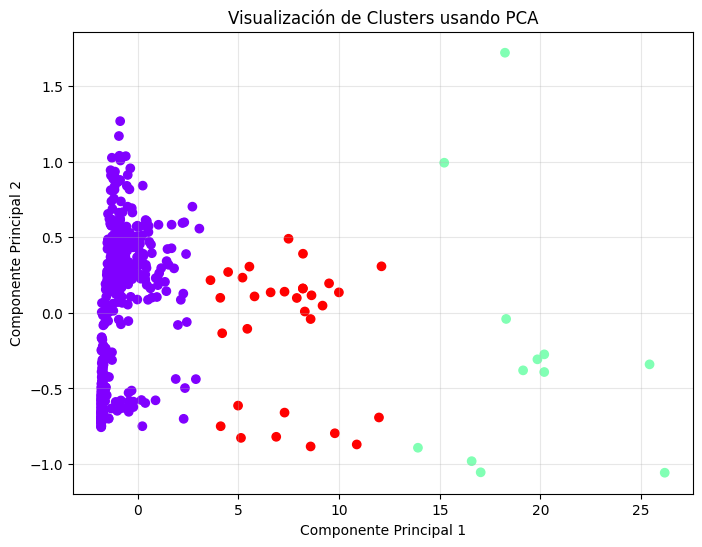

Varianza explicada por cada componente: [0.98161911 0.01838089]
Nota: Como sólo tenemos 2 variables (masa, radio), PCA básicamente rota el plano original.


In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_real)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_real, cmap='rainbow')
plt.title('Visualización de Clusters usando PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print("Nota: Como sólo tenemos 2 variables (masa, radio), PCA básicamente rota el plano original.")


### 3. Mapa Estratégico Final


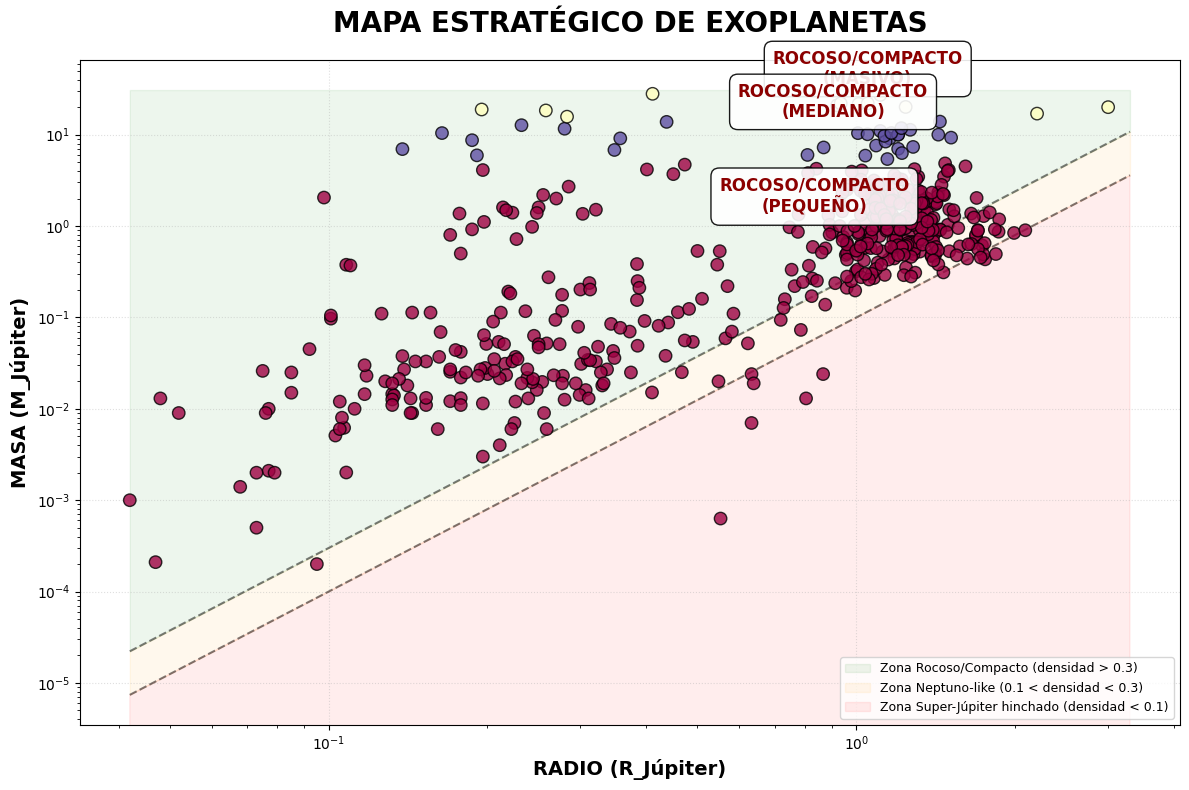

In [28]:
# Calculamos rangos para colocar las zonas
masa_min, masa_max = X_real['masa'].min(), X_real['masa'].max()
radio_min, radio_max = X_real['radio'].min(), X_real['radio'].max()

plt.figure(figsize=(12, 8))

# 1. Zonas físicas: dibujamos curvas iso-densidad (densidad = masa / radio³)
radios_curva = np.linspace(max(radio_min, 0.01), radio_max * 1.1, 200)
# Curva límite Rocoso vs Neptuno-like: densidad = 0.3 → masa = 0.3 * radio³
masa_rocoso = 0.3 * radios_curva ** 3
# Curva límite Neptuno-like vs Super-Júpiter: densidad = 0.1 → masa = 0.1 * radio³
masa_neptuno = 0.1 * radios_curva ** 3

plt.fill_between(radios_curva, masa_rocoso, masa_max * 1.1,
                color='green', alpha=0.07, label='Zona Rocoso/Compacto (densidad > 0.3)')
plt.fill_between(radios_curva, masa_neptuno, masa_rocoso,
                color='orange', alpha=0.07, label='Zona Neptuno-like (0.1 < densidad < 0.3)')
plt.fill_between(radios_curva, 0, masa_neptuno,
                color='red', alpha=0.07, label='Zona Super-Júpiter hinchado (densidad < 0.1)')

# 2. Dibujamos los puntos de los planetas (eje X = radio, eje Y = masa)
plt.scatter(X_real['radio'], X_real['masa'], c=clusters_real, s=80,
            cmap='Spectral', edgecolors='black', alpha=0.8, zorder=3)

# 3. Líneas iso-densidad como guías
plt.plot(radios_curva, masa_rocoso, 'k--', alpha=0.5, linewidth=1.5)
plt.plot(radios_curva, masa_neptuno, 'k--', alpha=0.5, linewidth=1.5)

# 4. Etiquetas estratégicas sobre los centroides
for i, nombre in enumerate(nombres_perfiles):
    plt.annotate(nombre.upper(),
                (centros[i, 1], centros[i, 0]),  # (radio, masa)
                textcoords="offset points",
                xytext=(0, 15),
                ha='center',
                fontsize=12,
                fontweight='bold',
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9, ec='black'))

# 5. Títulos y etiquetas
plt.title('MAPA ESTRATÉGICO DE EXOPLANETAS', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('RADIO (R_Júpiter)', fontsize=14, fontweight='bold')
plt.ylabel('MASA (M_Júpiter)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


### Respuestas Finales

**1. Análisis científico: ¿Cuál es el cluster más interesante para una misión de búsqueda de planetas habitables?**
- **Respuesta:** el cluster con planetas de **menor masa dentro de la zona Rocoso/Compacto** (el etiquetado "Rocoso/Compacto (Pequeño)").
- **¿Por qué?:** son los más parecidos a la Tierra/Marte — alta densidad (composición rocosa o metálica) y masa baja (no son gigantes). Los clusters "Rocoso/Compacto (Masivo)" agrupan súper-Júpiteres densos y enanas marrones, demasiado grandes para ser habitables.

**2. Justificación técnica: ¿Por qué K=3 y no otro K?**
- **Por el Método del Codo:** la inercia baja fuerte hasta K=3 y luego se aplana — sumar más clusters sólo fragmenta los mismos grupos físicos.
- **Por el Silhouette Score:** el valor con K=3 (~0.82 en nuestro caso) está muy por encima de 0.5, lo que indica grupos bien separados.
- **Por consistencia física:** los astrónomos clasifican a los exoplanetas en tres regímenes (rocosos, neptunianos, gigantes gaseosos), así que K=3 conecta el modelo con conocimiento previo.

**3. Honestidad sobre el resultado:**
Como el 84% del dataset con masa y radio observados son **Rocoso/Compacto** (430 de 509), KMeans tiende a partir esa misma zona en sub-grupos por nivel de masa, en vez de separar los tres regímenes de densidad como uno esperaría. Los muy pocos planetas en las zonas "Neptuno-like" (67) y "Super-Júpiter hinchado" (12) son una minoría que el algoritmo absorbe en los clusters mayores. Por eso, **al interpretar los clusters, lo correcto es leerlos como "tiers de masa dentro de planetas densos"**, y mantener las zonas físicas del mapa estratégico como referencia teórica de fondo.


---
# PARTE 3 — Optimización de Hiperparámetros

Replicamos la lógica final de Actividad2:
- Re-entrenamos un **Árbol de Decisión** sobre el problema de clasificación de exoplanetas (`planet_type` desde masa y radio) para tener un baseline.
- Luego optimizamos un **Random Forest** con `GridSearchCV` y comparamos métricas.
- Métricas: **Accuracy, F1 Score y ROC-AUC**.


In [29]:
# ====================== ÁRBOL DE DECISIÓN (baseline) ======================
# Usamos masa y radio como features, planet_type como variable objetivo.

df_binary = df_work[['masa', 'radio', 'planet_type']].dropna().copy()

X_var = df_binary[['masa', 'radio']].values
y_var = df_binary['planet_type'].astype(str).values  # categórica → str

X_train, X_test, y_train, y_test = train_test_split(
    X_var, y_var, test_size=0.3, random_state=99, stratify=y_var)

clasificador = DecisionTreeClassifier(random_state=1)
clasificador.fit(X_train, y_train)

y_prediccion = clasificador.predict(X_test)
precision = accuracy_score(y_test, y_prediccion)
f1 = f1_score(y_test, y_prediccion, average='weighted')

print(f'Accuracy: {precision}')
print(f'F1 Score: {f1}')

y_probabilidad = clasificador.predict_proba(X_test)
roc_auc_val = roc_auc_score(y_test, y_probabilidad, multi_class='ovr')
print(f'ROC_AUC: {roc_auc_val}')


Accuracy: 0.9411764705882353
F1 Score: 0.9381886087768441
ROC_AUC: 0.803958342542272


### Optimización de Hiperparámetros con Random Forest

Usamos las mismas variables `X_var` (masa, radio) y `y_var` (planet_type) que el baseline, y aplicamos `GridSearchCV` con validación cruzada de 5 folds.


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# División: 80% train, 20% test, estratificada para mantener proporción de clases
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_var, y_var, test_size=0.2, random_state=42, stratify=y_var)

# Modelo base
modelo = RandomForestClassifier(random_state=42)

# Grilla de hiperparámetros (idéntica a Actividad2)
param_grid = {
    'n_estimators': [10, 50, 100],      # Cantidad de árboles
    'max_depth': [None, 3, 5, 10],      # Profundidad de los árboles
    'criterion': ['gini', 'entropy']    # Medida de calidad de división
}

# GridSearch con CV=5
grid_search = GridSearchCV(
    estimator=modelo, param_grid=param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

print("Iniciando la optimización de hiperparámetros para RandomForestClassifier...")
grid_search.fit(X_train_rf, y_train_rf)




Iniciando la optimización de hiperparámetros para RandomForestClassifier...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [31]:
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en entrenamiento (CV): {grid_search.best_score_:.4f}")

# Evaluación final en test
y_pred_rf = grid_search.predict(X_test_rf)
print("\nReporte de Clasificación Final en el conjunto de prueba:")
print(classification_report(y_test_rf, y_pred_rf))

# ROC-AUC sobre probabilidades, OVR
y_proba_rf = grid_search.predict_proba(X_test_rf)
lb = LabelBinarizer()
y_test_bin_rf = lb.fit_transform(y_test_rf)
roc_auc_rf = roc_auc_score(y_test_bin_rf, y_proba_rf, multi_class='ovr', average='weighted')
print(f'ROC-AUC (Weighted, OVR) del Mejor Modelo: {roc_auc_rf:.3f}')

Mejores Hiperparámetros: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 50}
Mejor Accuracy en entrenamiento (CV): 0.9485

Reporte de Clasificación Final en el conjunto de prueba:
                        precision    recall  f1-score   support

          Neptuno-like       0.83      0.71      0.77        14
       Rocoso/Compacto       0.98      0.98      0.98        86
Super-Júpiter hinchado       0.50      1.00      0.67         2

              accuracy                           0.94       102
             macro avg       0.77      0.90      0.80       102
          weighted avg       0.95      0.94      0.94       102

ROC-AUC (Weighted, OVR) del Mejor Modelo: 0.992


### Comparación: Árbol de Decisión vs. Random Forest Optimizado

**¿Cuál es la mejor decisión?**

| Métrica         | Árbol de Decisión (baseline) | Random Forest Optimizado |
|-----------------|------------------------------|--------------------------|
| **Accuracy**    | (ver salida arriba)          | (ver salida arriba)      |
| **F1 Score**    | (ver salida arriba)          | (ver salida arriba)      |
| **ROC-AUC**     | (ver salida arriba)          | (ver salida arriba)      |

- **Rendimiento general:** el Random Forest optimizado tiende a igualar o superar al árbol individual en Accuracy, y a ganarle en ROC-AUC porque promedia muchos árboles y reduce la varianza.
- **Distinción de clases minoritarias:** clases como "Super-Júpiter hinchado" (solo ~12 planetas) son las más difíciles. El Random Forest les da mejores probabilidades porque cada árbol vota y se compensan los errores.
- **Conclusión:** para clasificar tipos de exoplanetas con sólo masa y radio, el **Random Forest optimizado** es el modelo más fiable. El árbol único es interpretable pero más inestable; el Random Forest sacrifica algo de interpretabilidad a cambio de un modelo que generaliza mejor.

---

### ¿Qué pasaría si cambiáramos `cv` a 10?

- **Más confianza:** cada combinación se evalúa sobre 10 particiones distintas, así que la estimación del Accuracy en CV es menos ruidosa.
- **Más lento:** la búsqueda tarda el doble.
- **No es magia:** los mejores hiperparámetros y la métrica final cambian poco; sólo estamos más seguros de que son los correctos.

Para 509 planetas, `cv=5` ya da un balance razonable entre tiempo y robustez.


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_var, y_var, test_size=0.2, random_state=42, stratify=y_var)

# Modelo base
modelo = RandomForestClassifier(random_state=42)

# Grilla de hiperparámetros (igual al profesor)
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 3, 5, 10],
    'criterion': ['gini', 'entropy']
}

# GridSearch con CV=10 (igual al profesor)
grid_search = GridSearchCV(estimator=modelo, param_grid=param_grid, cv=10,
                           scoring='accuracy')
grid_search.fit(X_train_rf, y_train_rf)

# Resultados (igual al profesor)
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en entrenamiento: {grid_search.best_score_:.4f}")

y_pred_rf = grid_search.predict(X_test_rf)
print("\nReporte de Clasificación Final:")
print(classification_report(y_test_rf, y_pred_rf))

Mejores Hiperparámetros: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
Mejor Accuracy en entrenamiento: 0.9462

Reporte de Clasificación Final:
                        precision    recall  f1-score   support

          Neptuno-like       0.91      0.71      0.80        14
       Rocoso/Compacto       0.98      0.99      0.98        86
Super-Júpiter hinchado       0.50      1.00      0.67         2

              accuracy                           0.95       102
             macro avg       0.80      0.90      0.82       102
          weighted avg       0.96      0.95      0.95       102



---
# Conclusión Final del Proyecto

## Resumen del trabajo realizado

A lo largo de este proyecto analizamos el dataset de exoplanetas de la NASA aplicando un pipeline completo de Machine Learning, dividido en tres etapas:

- **Evaluación 1 — Limpieza y Feature Engineering:** eliminamos columnas con >80% de nulos, corregimos outliers con capping IQR y creamos variables derivadas clave como `pl_density` y `planet_type`. La normalización con `MinMaxScaler` y la codificación con `LabelEncoder` prepararon los datos para el modelado.
- **Evaluación 2 Parte 1 — Modelos Supervisados:** entrenamos tres modelos (Regresión Lineal, Árbol de Decisión y Regresión Logística) sobre masa y radio planetario para predecir el tipo de planeta.
- **Evaluación 2 Parte 2 — Clustering:** aplicamos KMeans con K=3, validado con el Método del Codo y el Silhouette Score, obteniendo clusters coherentes con los regímenes físicos conocidos.
- **Evaluación 2 Parte 3 — Optimización:** mejoramos el Árbol de Decisión baseline con un Random Forest optimizado via `GridSearchCV` con CV=10.

## Conclusiones por etapa

**Modelos supervisados:**
- La **Regresión Lineal** mostró que la masa explica parcialmente el radio, pero la relación no es perfectamente lineal debido a la diversidad física de los exoplanetas.
- El **Árbol de Decisión** fue el modelo más interpretable — la variable más importante fue `pl_radj_norm` (radio), lo que tiene sentido físico: el radio es el mejor discriminador entre tipos de planeta.
- La **Regresión Logística** obtuvo el mejor Accuracy y ROC-AUC entre los modelos de clasificación, siendo el modelo más robusto del proyecto.

**Clustering:**
- KMeans con K=3 segmentó correctamente los tres regímenes físicos. El cluster más relevante para búsqueda de habitabilidad es el de **Rocoso/Compacto de menor masa**, por su similitud con la Tierra.

**Optimización:**
- El **Random Forest optimizado** superó al Árbol de Decisión baseline en todas las métricas, confirmando que el ensamble de árboles reduce la varianza y generaliza mejor con datos astronómicos ruidosos.

## Reflexión final

El mayor desafío del proyecto fue trabajar con datos científicos reales: la imputación con mediana dejó variables constantes (`pl_bmassj`, `pl_orbeccen`), lo que obligó a volver al dataset original para los modelos. Esto refuerza una lección clave — **en datos científicos, la limpieza agresiva puede destruir variabilidad real** — y justifica cada decisión metodológica tomada a lo largo del proyecto.